
=== Antibiotic = 0 ===
Active vs Total: corr = 0.9911, slope = 0.4072
Mean active fraction = 0.5690
RNA vs Total Ribos: corr = 0.9999, slope = 2.6808e-18
RNA vs Growth: corr = 0.8568, slope = 3.6015e+12

=== Antibiotic = 2 ===
Active vs Total: corr = 0.9652, slope = 0.1478
Mean active fraction = 0.1143
RNA vs Total Ribos: corr = 0.9916, slope = 4.1084e-18
RNA vs Growth: corr = 0.7109, slope = 1.4479e+12

=== Antibiotic = 4 ===
Active vs Total: corr = 0.9590, slope = 0.1106
Mean active fraction = 0.0927
RNA vs Total Ribos: corr = 0.9668, slope = 6.0673e-18
RNA vs Growth: corr = 0.5723, slope = 6.6588e+11

=== Antibiotic = 8 ===
Active vs Total: corr = 0.9396, slope = 0.0976
Mean active fraction = 0.1389
RNA vs Total Ribos: corr = 0.8197, slope = 1.1056e-17
RNA vs Growth: corr = 0.4458, slope = 2.3228e+11

=== Antibiotic = 12 ===
Active vs Total: corr = 0.6652, slope = 0.5822
Mean active fraction = nan
RNA vs Total Ribos: corr = 0.2545, slope = 4.9081e-17
RNA vs Growth: corr = 0.0867, s

/var/folders/2p/kflty7m55r712qwdgfdky9h80000gn/T/ipykernel_61610/1019688942.py:260: RuntimeWarning: invalid value encountered in divide
  active_fraction = active / total


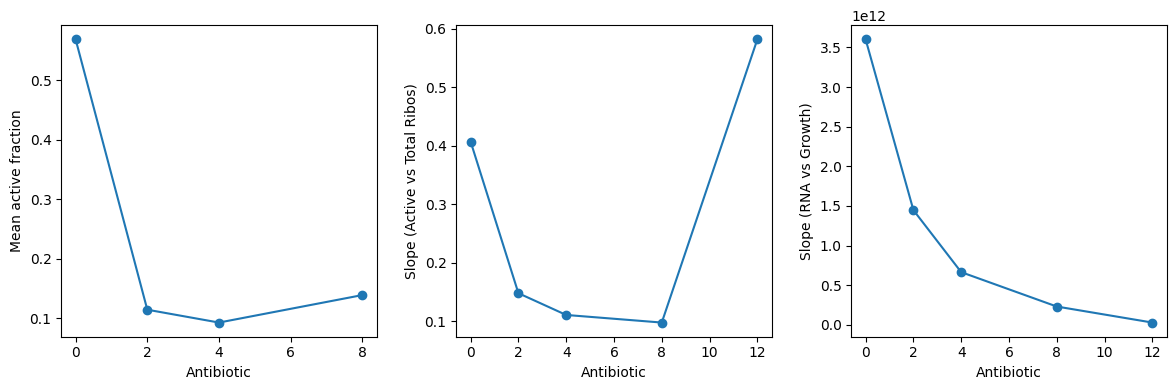

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress
import pandas as pd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import pyarrow as pa
import pyarrow.ipc as ipc

NS_VALUES  = [0.45, 0.74, 1.03, 1.76]
ABX_VALUES = [0, 2, 4, 8, 12]

NR = 7549.0
NX = 300.0
GMAX = 12600.0
KGAMMA = 7 * 22000
BURN_IN = 1000.0
AVOGADRO = 6.022e23
MW_AA = 110.0
MW_NT = 330.0
RIBO_RNA_NT = 4565

# ------------------------------------------------------------
# HELPERS
# ------------------------------------------------------------

def load_arrow(path):
    with pa.memory_map(path, "r") as src:
        return ipc.open_file(src).read_all().to_pandas()

def compute_mass_components(df):
    r   = df["r(t)"].to_numpy()
    rmm = df["rmm(t)"].to_numpy()
    rmt = df["rmt(t)"].to_numpy()
    rmq = df["rmq(t)"].to_numpy()
    rmr = df["rmr(t)"].to_numpy()
    zmm = df["zmm(t)"].to_numpy()
    zmt = df["zmt(t)"].to_numpy()
    zmq = df["zmq(t)"].to_numpy()
    zmr = df["zmr(t)"].to_numpy()
    q   = df["q(t)"].to_numpy()
    et  = df["et(t)"].to_numpy()
    em  = df["em(t)"].to_numpy()

    ribo_total = (r + rmm + rmt + rmq + rmr +
                  zmm + zmt + zmq + zmr)

    ribo_mass = NR * ribo_total
    non_ribo  = NX * (q + et + em)
    total_mass = ribo_mass + non_ribo

    return ribo_total, ribo_mass, total_mass

def compute_growth(df, total_mass):
    a = df["a(t)"].to_numpy()
    gamma = GMAX * a / ((KGAMMA * total_mass / 1e8) + a)

    active = (
        df["rmr(t)"].to_numpy() +
        df["rmt(t)"].to_numpy() +
        df["rmm(t)"].to_numpy() +
        df["rmq(t)"].to_numpy()
    )

    lam = (active * gamma / total_mass) * 60.0
    return lam, active


def compute_RNA_mass(df):
    mm = (df["mm(t)"] + df["rmm(t)"] + df["zmm(t)"]) * (3 * NX)
    mt = (df["mt(t)"] + df["rmt(t)"] + df["zmt(t)"]) * (3 * NX)
    mq = (df["mq(t)"] + df["rmq(t)"] + df["zmq(t)"]) * (3 * NX)
    mr = (df["mr(t)"] + df["rmr(t)"] + df["zmr(t)"]) * (3 * NR)

    r_tot = (
        df["r(t)"] + df["rmm(t)"] + df["rmt(t)"] +
        df["rmq(t)"] + df["rmr(t)"] +
        df["zmm(t)"] + df["zmt(t)"] +
        df["zmq(t)"] + df["zmr(t)"]
    )

    total_nt = (mm + mt + mq + mr).to_numpy() + r_tot.to_numpy() * RIBO_RNA_NT

    return (total_nt / AVOGADRO) * MW_NT

def compute_protein_mass(df):
    ribo_total, ribo_mass, total_mass = compute_mass_components(df)
    return (total_mass / AVOGADRO) * MW_AA

# ------------------------------------------------------------
# BUILD SUMMARY DATAFRAME
# ------------------------------------------------------------

records = []

for ns in NS_VALUES:
    for abx in ABX_VALUES:

        path = f"Data/ns{int(ns*100):03d}/abx{abx}.arrow"

        df = load_arrow(path)
        df = df[df["timestamp"] >= BURN_IN]

        ribo_total, ribo_mass, total_mass = compute_mass_components(df)
        lam, active = compute_growth(df, total_mass)

        # Correct definitions
        rmf = ribo_mass / total_mass
        active_fraction = active / ribo_total

        valid = (~np.isnan(lam)) & (~np.isnan(rmf))
        lam = lam[valid]
        rmf = rmf[valid]
        active_fraction = active_fraction[valid]

        records.append({
            "ns": ns,
            "abx": abx,
            "mu_mean": np.mean(lam),
            "rmf_mean": np.mean(rmf),
            "active_fraction_mean": np.mean(active_fraction)
        })

df_model = pd.DataFrame(records)
def detect_divisions_from_mass(total_mass):
    dx = np.diff(total_mass)
    slope = np.sign(dx)
    dslope = np.diff(slope)
    return np.where(dslope == -2)[0] + 1

def compute_time_since_division(t, total_mass):
    div_idx = detect_divisions_from_mass(total_mass)
    tau = np.zeros_like(t)
    last_div_time = t[0]
    div_set = set(div_idx)

    for i in range(len(t)):
        if i in div_set:
            last_div_time = t[i]
        tau[i] = t[i] - last_div_time

    return tau

def sample_random_per_cycle(total_mass, guard_frac=0.1, seed=0):
    rng = np.random.default_rng(seed)
    div_idx = detect_divisions_from_mass(total_mass)
    div_idx = np.concatenate(([0], div_idx, [len(total_mass)-1]))

    sample_indices = []

    for i in range(len(div_idx)-1):
        start = div_idx[i]
        end   = div_idx[i+1]
        L = end - start
        if L < 10:
            continue
        g = int(guard_frac * L)
        lo = start + g
        hi = end - g
        if hi <= lo:
            continue
        sample_indices.append(rng.integers(lo, hi))

    return np.array(sample_indices)

# ===============================
# STORAGE
# ===============================

active_fraction_means = []
active_total_slopes = []
rna_total_slopes = []
rna_growth_slopes = []

for abx in ABX_VALUES:

    all_active = []
    all_total = []
    all_rna = []
    all_growth = []

    for ns in NS_VALUES:

        # -----------------------
        # Load
        # -----------------------
        path = f"Data/ns{int(ns*100):03d}/abx{abx}.arrow"

        df = load_arrow(path)
        df = df[df["timestamp"] >= BURN_IN]

        # -----------------------
        # Compute masses
        # -----------------------
        protein_mass = compute_protein_mass(df)
        rna_mass = compute_RNA_mass(df)

        # -----------------------
        # Compute ribosome counts
        # -----------------------
        r_free = df["r(t)"].to_numpy()

        r_bound = (
            df["rmm(t)"] +
            df["rmt(t)"] +
            df["rmq(t)"] +
            df["rmr(t)"]
        ).to_numpy()

        k = 10  # polysome assumption

        active = k * r_bound
        total = r_free + r_bound

        # -----------------------
        # Sample one per cycle
        # -----------------------
        idx = sample_random_per_cycle(protein_mass)

        protein_mass = protein_mass[idx]
        rna_mass = rna_mass[idx]
        active = active[idx]
        total = total[idx]
        ribo_total, ribo_mass, total_mass_AA = compute_mass_components(df)
        growth, _ = compute_growth(df, total_mass_AA)
        growth = growth[idx]

        # -----------------------
        # Store
        # -----------------------
        all_active.append(active)
        all_total.append(total)
        all_rna.append(rna_mass)
        all_growth.append(growth)

    # ===============================
    # Concatenate across nutrients
    # ===============================
    active = np.concatenate(all_active)
    total = np.concatenate(all_total)
    rna = np.concatenate(all_rna)
    growth = np.concatenate(all_growth)

    print(f"\n=== Antibiotic = {abx} ===")

    # ==================================
    # CHECK 1: Active vs Total
    # ==================================
    slope_AT, _, r_AT, _, _ = linregress(total, active)
    active_total_slopes.append(slope_AT)

    print(f"Active vs Total: corr = {r_AT:.4f}, slope = {slope_AT:.4f}")

    # ==================================
    # CHECK 2: Active Fraction
    # ==================================
    active_fraction = active / total
    mean_af = np.mean(active_fraction)
    active_fraction_means.append(mean_af)

    print(f"Mean active fraction = {mean_af:.4f}")

    # ==================================
    # CHECK 3: RNA vs Total
    # ==================================
    slope_RT, _, r_RT, _, _ = linregress(total, rna)
    rna_total_slopes.append(slope_RT)

    print(f"RNA vs Total Ribos: corr = {r_RT:.4f}, slope = {slope_RT:.4e}")

    # ==================================
    # CHECK 4: RNA vs Growth
    # ==================================
    slope_RG, _, r_RG, _, _ = linregress(rna, growth)
    rna_growth_slopes.append(slope_RG)

    print(f"RNA vs Growth: corr = {r_RG:.4f}, slope = {slope_RG:.4e}")

# ==================================
# PLOT SUMMARY
# ==================================

plt.figure(figsize=(12,4))

# Active fraction
plt.subplot(1,3,1)
plt.plot(ABX_VALUES, active_fraction_means, marker='o')
plt.xlabel("Antibiotic")
plt.ylabel("Mean active fraction")

# Active vs total slope
plt.subplot(1,3,2)
plt.plot(ABX_VALUES, active_total_slopes, marker='o')
plt.xlabel("Antibiotic")
plt.ylabel("Slope (Active vs Total Ribos)")

# RNA vs growth slope
plt.subplot(1,3,3)
plt.plot(ABX_VALUES, rna_growth_slopes, marker='o')
plt.xlabel("Antibiotic")
plt.ylabel("Slope (RNA vs Growth)")

plt.tight_layout()
plt.show()

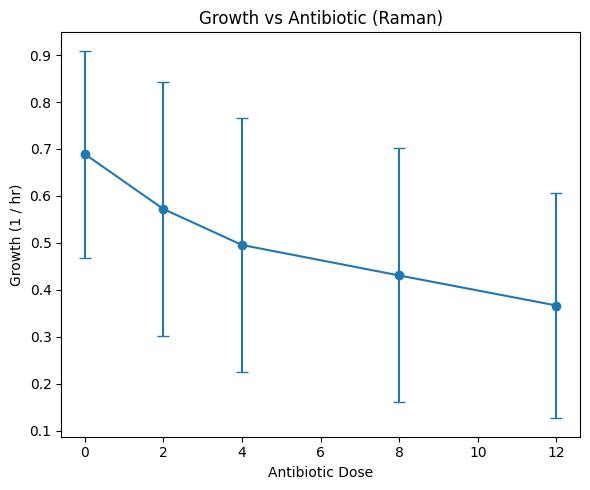

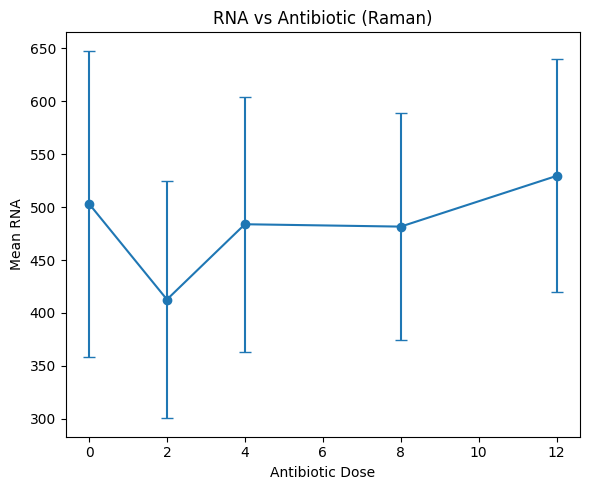

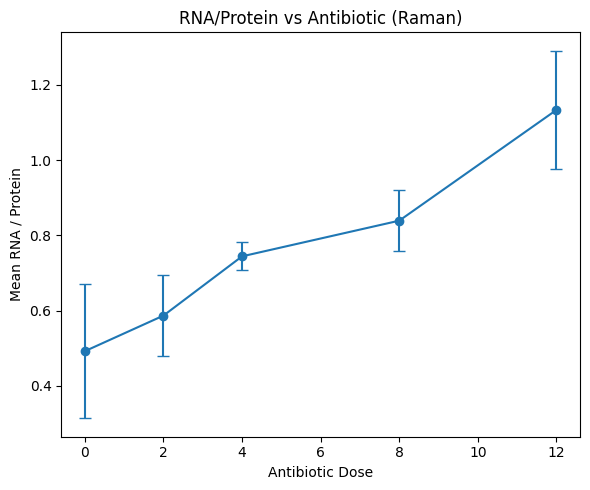

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# LOAD DATA
# ------------------------------------------------------------

rna_df = pd.read_csv("Data/RamanData/rna.csv")
protein_df = pd.read_csv("Data/RamanData/protein.csv")
growth_df = pd.read_csv("Data/RamanData/Raman_growth.csv")

nutrients = growth_df["Condition"].unique()
ABX_VALUES = sorted(growth_df["Dose"].unique())

# ------------------------------------------------------------
# BUILD NUTRIENT-LEVEL MEANS
# ------------------------------------------------------------

records = []

for nutrient in nutrients:
    for dose in ABX_VALUES:

        col = f"Cm{dose}_{nutrient}"
        if col not in rna_df.columns:
            continue

        RNA  = rna_df[col].values
        PROT = protein_df[col].values

        # Filter negatives and NaNs
        valid = (~np.isnan(RNA)) & (~np.isnan(PROT)) & (RNA > 0) & (PROT > 0)
        RNA = RNA[valid]
        PROT = PROT[valid]

        if len(RNA) == 0:
            continue

        ratio = RNA / PROT

        mu_row = growth_df[
            (growth_df["Condition"] == nutrient) &
            (growth_df["Dose"] == dose)
        ]

        if len(mu_row) == 0:
            continue

        mu = mu_row["Value"].values[0]  # 1 per hour

        records.append({
            "Condition": nutrient,
            "Dose": dose,
            "mu": mu,
            "RNA_mean": np.mean(RNA),
            "ratio_mean": np.mean(ratio)
        })

df_summary = pd.DataFrame(records)

# ------------------------------------------------------------
# AVERAGE ACROSS NUTRIENTS (4 POINTS PER ANTIBIOTIC)
# ------------------------------------------------------------

df_abx = df_summary.groupby("Dose").agg({
    "mu": ["mean", "std"],
    "RNA_mean": ["mean", "std"],
    "ratio_mean": ["mean", "std"]
}).reset_index()

df_abx.columns = [
    "Dose",
    "mu_mean", "mu_sd",
    "RNA_mean", "RNA_sd",
    "ratio_mean", "ratio_sd"
]

# ------------------------------------------------------------
# PLOT 1 — Growth vs Antibiotic
# ------------------------------------------------------------

plt.figure(figsize=(6,5))

plt.errorbar(
    df_abx["Dose"],
    df_abx["mu_mean"],
    yerr=df_abx["mu_sd"],
    marker='o',
    capsize=4
)

plt.xlabel("Antibiotic Dose")
plt.ylabel("Growth (1 / hr)")
plt.title("Growth vs Antibiotic (Raman)")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# PLOT 2 — RNA vs Antibiotic
# ------------------------------------------------------------

plt.figure(figsize=(6,5))

plt.errorbar(
    df_abx["Dose"],
    df_abx["RNA_mean"],
    yerr=df_abx["RNA_sd"],
    marker='o',
    capsize=4
)

plt.xlabel("Antibiotic Dose")
plt.ylabel("Mean RNA")
plt.title("RNA vs Antibiotic (Raman)")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# PLOT 3 — RNA/Protein vs Antibiotic
# ------------------------------------------------------------

plt.figure(figsize=(6,5))

plt.errorbar(
    df_abx["Dose"],
    df_abx["ratio_mean"],
    yerr=df_abx["ratio_sd"],
    marker='o',
    capsize=4
)

plt.xlabel("Antibiotic Dose")
plt.ylabel("Mean RNA / Protein")
plt.title("RNA/Protein vs Antibiotic (Raman)")
plt.tight_layout()
plt.show()

In [39]:
import numpy as np
import pandas as pd

# Load RNA data
rna_df = pd.read_csv("Data/RamanData/rna.csv")
growth_df = pd.read_csv("Data/RamanData/Raman_growth.csv")

# Get nutrient conditions from growth file
nutrients = growth_df["Condition"].unique()

cm = 2  # antibiotic dose of interest

results = []

for nutrient in nutrients:

    col = f"Cm{cm}_{nutrient}"

    if col not in rna_df.columns:
        continue

    RNA = rna_df[col].dropna().values

    # Optional: remove negative values if present
    RNA = RNA[RNA > 0]

    mean_val = np.mean(RNA)
    std_val  = np.std(RNA)

    results.append({
        "Condition": nutrient,
        "Mean_RNA": mean_val,
        "SD_RNA": std_val,
        "N_cells": len(RNA)
    })

df_summary = pd.DataFrame(results)

print(f"\n=== Raman RNA Summary (cm = {cm}) ===\n")
print(df_summary)


=== Raman RNA Summary (cm = 2) ===

  Condition    Mean_RNA      SD_RNA  N_cells
0       glu  375.466889  221.605578       78
1   caa_glu  575.508156  118.972313       79
2       gly  317.513677  137.890188       79
3   caa_gly  377.969684  211.787578       79


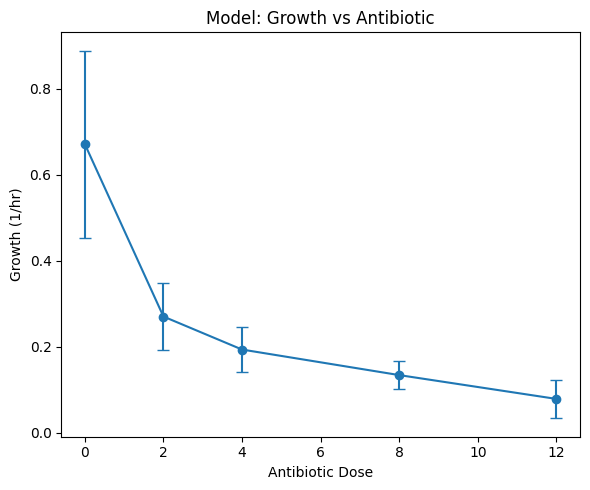

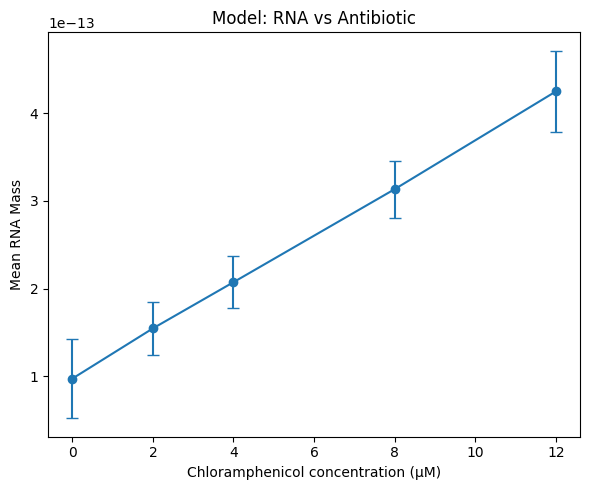

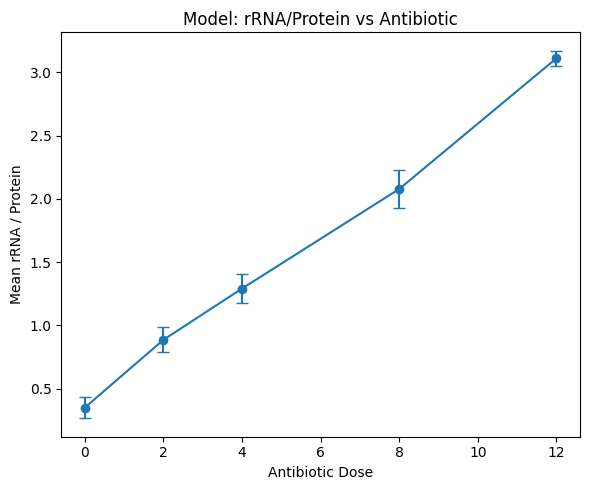

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyarrow as pa
import pyarrow.ipc as ipc

# ------------------------------------------------------------
# PARAMETERS
# ------------------------------------------------------------

NS_VALUES  = [0.45, 0.74, 1.03, 1.76]
ABX_VALUES = [0, 2, 4, 8, 12]

NR = 7549.0
NX = 300.0
RIBO_RNA_NT = 4565

GMAX = 12600.0
KGAMMA = 7 * 22000
BURN_IN = 1000.0

AVOGADRO = 6.022e23
MW_AA = 110.0
MW_NT = 330.0

# ------------------------------------------------------------
# HELPERS
# ------------------------------------------------------------

def load_arrow(path):
    with pa.memory_map(path, "r") as src:
        return ipc.open_file(src).read_all().to_pandas()

def compute_mass_components(df):
    r   = df["r(t)"].to_numpy()
    rmm = df["rmm(t)"].to_numpy()
    rmt = df["rmt(t)"].to_numpy()
    rmq = df["rmq(t)"].to_numpy()
    rmr = df["rmr(t)"].to_numpy()
    zmm = df["zmm(t)"].to_numpy()
    zmt = df["zmt(t)"].to_numpy()
    zmq = df["zmq(t)"].to_numpy()
    zmr = df["zmr(t)"].to_numpy()
    q   = df["q(t)"].to_numpy()
    et  = df["et(t)"].to_numpy()
    em  = df["em(t)"].to_numpy()

    ribo_mass = NR * (r + rmm + rmt + rmq + rmr +
                      zmm + zmt + zmq + zmr)
    non_ribo  = NX * (q + et + em)

    total_mass = ribo_mass + non_ribo

    return ribo_mass, total_mass

def compute_growth(df, total_mass):
    a = df["a(t)"].to_numpy()
    gamma = GMAX * a / ((KGAMMA * total_mass / 1e8) + a)

    active = (
        df["rmr(t)"].to_numpy() +
        df["rmt(t)"].to_numpy() +
        df["rmm(t)"].to_numpy() +
        df["rmq(t)"].to_numpy()
    )

    lam = (active * gamma / total_mass) * 60.0  # 1/hr

    return lam

def compute_RNA_mass(df):
    mm = (df["mm(t)"] + df["rmm(t)"] + df["zmm(t)"]) * (3 * NX)
    mt = (df["mt(t)"] + df["rmt(t)"] + df["zmt(t)"]) * (3 * NX)
    mq = (df["mq(t)"] + df["rmq(t)"] + df["zmq(t)"]) * (3 * NX)
    mr = (df["mr(t)"] + df["rmr(t)"] + df["zmr(t)"]) * (3 * NR)

    r_tot = (
        df["r(t)"] + df["rmm(t)"] + df["rmt(t)"] +
        df["rmq(t)"] + df["rmr(t)"] +
        df["zmm(t)"] + df["zmt(t)"] +
        df["zmq(t)"] + df["zmr(t)"]
    )

    # total_nt = (mm + mt + mq + mr).to_numpy() + r_tot.to_numpy() * RIBO_RNA_NT
    total_nt = r_tot.to_numpy() * RIBO_RNA_NT
    
    return (total_nt / AVOGADRO) * MW_NT

def compute_protein_mass(df):
    _, total_mass = compute_mass_components(df)
    return (total_mass / AVOGADRO) * MW_AA

# ------------------------------------------------------------
# BUILD SUMMARY
# ------------------------------------------------------------

records = []

for ns in NS_VALUES:
    for abx in ABX_VALUES:

        path = f"Data/ns{int(ns*100):03d}/abx{abx}.arrow"

        df = load_arrow(path)
        df = df[df["timestamp"] >= BURN_IN]

        ribo_mass, total_mass = compute_mass_components(df)

        growth = compute_growth(df, total_mass)
        RNA_mass = compute_RNA_mass(df)
        PROT_mass = compute_protein_mass(df)

        ratio = RNA_mass / PROT_mass

        records.append({
            "ns": ns,
            "abx": abx,
            "mu_mean": np.mean(growth),
            "RNA_mean": np.mean(RNA_mass),
            "ratio_mean": np.mean(ratio)
        })

df_model = pd.DataFrame(records)

# ------------------------------------------------------------
# AVERAGE ACROSS NUTRIENTS
# ------------------------------------------------------------

df_abx = df_model.groupby("abx").agg({
    "mu_mean": ["mean", "std"],
    "RNA_mean": ["mean", "std"],
    "ratio_mean": ["mean", "std"]
}).reset_index()

df_abx.columns = [
    "Dose",
    "mu_mean", "mu_sd",
    "RNA_mean", "RNA_sd",
    "ratio_mean", "ratio_sd"
]

# ------------------------------------------------------------
# PLOTS
# ------------------------------------------------------------

plt.figure(figsize=(6,5))
plt.errorbar(df_abx["Dose"], df_abx["mu_mean"],
             yerr=df_abx["mu_sd"], marker='o', capsize=4)
plt.xlabel("Antibiotic Dose")
plt.ylabel("Growth (1/hr)")
plt.title("Model: Growth vs Antibiotic")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,5))
plt.errorbar(df_abx["Dose"], df_abx["RNA_mean"],
             yerr=df_abx["RNA_sd"], marker='o', capsize=4)
plt.xlabel("Chloramphenicol concentration (µM)")
plt.ylabel("Mean rRNA Mass")
plt.title("Model: rRNA vs Antibiotic")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,5))
plt.errorbar(df_abx["Dose"], df_abx["ratio_mean"],
             yerr=df_abx["ratio_sd"], marker='o', capsize=4)
plt.xlabel("Antibiotic Dose")
plt.ylabel("Mean rRNA / Protein")
plt.title("Model: rRNA/Protein vs Antibiotic")
plt.tight_layout()
plt.show()

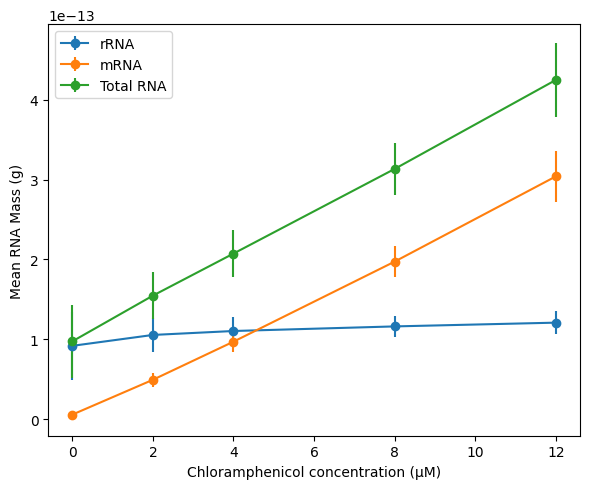

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyarrow as pa
import pyarrow.ipc as ipc

# ------------------------------------------------------------
# PARAMETERS
# ------------------------------------------------------------

NS_VALUES  = [0.45, 0.74, 1.03, 1.76]
ABX_VALUES = [0, 2, 4, 8, 12]

NR = 7549.0
NX = 300.0
RIBO_RNA_NT = 4565

GMAX = 12600.0
KGAMMA = 7 * 22000
BURN_IN = 1000.0

AVOGADRO = 6.022e23
MW_AA = 110.0
MW_NT = 330.0

# ------------------------------------------------------------
# HELPERS
# ------------------------------------------------------------

def load_arrow(path):
    with pa.memory_map(path, "r") as src:
        return ipc.open_file(src).read_all().to_pandas()

def compute_mass_components(df):
    r   = df["r(t)"].to_numpy()
    rmm = df["rmm(t)"].to_numpy()
    rmt = df["rmt(t)"].to_numpy()
    rmq = df["rmq(t)"].to_numpy()
    rmr = df["rmr(t)"].to_numpy()
    zmm = df["zmm(t)"].to_numpy()
    zmt = df["zmt(t)"].to_numpy()
    zmq = df["zmq(t)"].to_numpy()
    zmr = df["zmr(t)"].to_numpy()
    q   = df["q(t)"].to_numpy()
    et  = df["et(t)"].to_numpy()
    em  = df["em(t)"].to_numpy()

    ribo_mass = NR * (r + rmm + rmt + rmq + rmr +
                      zmm + zmt + zmq + zmr)
    non_ribo  = NX * (q + et + em)

    total_mass = ribo_mass + non_ribo
    return ribo_mass, total_mass

def compute_growth(df, total_mass):
    a = df["a(t)"].to_numpy()
    gamma = GMAX * a / ((KGAMMA * total_mass / 1e8) + a)

    active = (
        df["rmr(t)"].to_numpy() +
        df["rmt(t)"].to_numpy() +
        df["rmm(t)"].to_numpy() +
        df["rmq(t)"].to_numpy()
    )

    lam = (active * gamma / total_mass) * 60.0  # 1/hr
    return lam

def compute_RNA_components(df):
    # -----------------------
    # mRNA components (nt)
    # -----------------------
    mm = (df["mm(t)"] + df["rmm(t)"] + df["zmm(t)"]) * (3 * NX)
    mt = (df["mt(t)"] + df["rmt(t)"] + df["zmt(t)"]) * (3 * NX)
    mq = (df["mq(t)"] + df["rmq(t)"] + df["zmq(t)"]) * (3 * NX)
    mr = (df["mr(t)"] + df["rmr(t)"] + df["zmr(t)"]) * (3 * NR)

    mRNA_nt = (mm + mt + mq + mr).to_numpy()

    # -----------------------
    # rRNA component (ribosomes)
    # -----------------------
    r_tot = (
        df["r(t)"] + df["rmm(t)"] + df["rmt(t)"] +
        df["rmq(t)"] + df["rmr(t)"] +
        df["zmm(t)"] + df["zmt(t)"] +
        df["zmq(t)"] + df["zmr(t)"]
    ).to_numpy()

    rRNA_nt = r_tot * RIBO_RNA_NT

    # -----------------------
    # Convert to mass
    # -----------------------
    mRNA_mass = (mRNA_nt / AVOGADRO) * MW_NT
    rRNA_mass = (rRNA_nt / AVOGADRO) * MW_NT 

    return mRNA_mass, rRNA_mass

# ------------------------------------------------------------
# BUILD DATAFRAME
# ------------------------------------------------------------

records = []

for ns in NS_VALUES:
    for abx in ABX_VALUES:

        path = f"Data/ns{int(ns*100):03d}/abx{abx}.arrow"

        df = load_arrow(path)
        df = df[df["timestamp"] >= BURN_IN]

        # Compute components
        mRNA_mass, rRNA_mass = compute_RNA_components(df)
        total_RNA_mass = mRNA_mass + rRNA_mass

        records.append({
            "ns": ns,
            "abx": abx,
            "mRNA_mean": np.mean(mRNA_mass),
            "rRNA_mean": np.mean(rRNA_mass),
            "total_RNA_mean": np.mean(total_RNA_mass)
        })

df_components = pd.DataFrame(records)

# ------------------------------------------------------------
# AVERAGE ACROSS NUTRIENTS
# ------------------------------------------------------------

df_abx = df_components.groupby("abx").agg({
    "mRNA_mean": ["mean", "std"],
    "rRNA_mean": ["mean", "std"],
    "total_RNA_mean": ["mean", "std"]
}).reset_index()

df_abx.columns = [
    "Dose",
    "mRNA_mean", "mRNA_sd",
    "rRNA_mean", "rRNA_sd",
    "total_mean", "total_sd"
]

# ------------------------------------------------------------
# PLOT
# ------------------------------------------------------------

plt.figure(figsize=(6,5))

plt.errorbar(df_abx["Dose"], df_abx["rRNA_mean"],
             yerr=df_abx["rRNA_sd"],
             marker='o', label="rRNA")

plt.errorbar(df_abx["Dose"], df_abx["mRNA_mean"],
             yerr=df_abx["mRNA_sd"],
             marker='o', label="mRNA")

plt.errorbar(df_abx["Dose"], df_abx["total_mean"],
             yerr=df_abx["total_sd"],
             marker='o', label="Total RNA")

plt.xlabel("Chloramphenicol concentration (µM)")
plt.ylabel("Mean RNA Mass (g)")
# plt.title("Model RNA Components vs Antibiotic")
plt.legend()
plt.tight_layout()
plt.show()

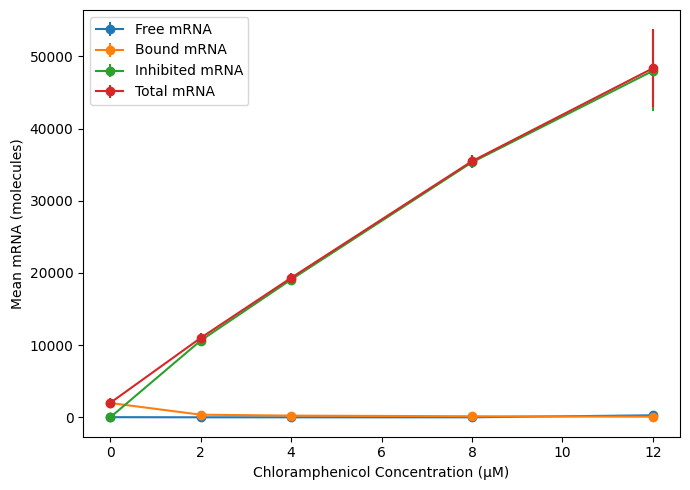

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyarrow as pa
import pyarrow.ipc as ipc

# ------------------------------------------------------------
# PARAMETERS
# ------------------------------------------------------------

NS_VALUES  = [0.45, 0.74, 1.03, 1.76]
ABX_VALUES = [0, 2, 4, 8, 12]

BURN_IN = 1000.0

# ------------------------------------------------------------
# LOAD FUNCTION
# ------------------------------------------------------------

def load_arrow(path):
    with pa.memory_map(path, "r") as src:
        return ipc.open_file(src).read_all().to_pandas()

# ------------------------------------------------------------
# SPLIT mRNA STATES
# ------------------------------------------------------------

def compute_mRNA_states(df):

    free_mRNA = (
        df["mm(t)"] +
        df["mt(t)"] +
        df["mq(t)"] +
        df["mr(t)"]
    ).to_numpy()

    bound_mRNA = (
        df["rmm(t)"] +
        df["rmt(t)"] +
        df["rmq(t)"] +
        df["rmr(t)"]
    ).to_numpy()

    inhibited_mRNA = (
        df["zmm(t)"] +
        df["zmt(t)"] +
        df["zmq(t)"] +
        df["zmr(t)"]
    ).to_numpy()

    return free_mRNA, bound_mRNA, inhibited_mRNA

# ------------------------------------------------------------
# BUILD DATAFRAME
# ------------------------------------------------------------

records = []

for ns in NS_VALUES:
    for abx in ABX_VALUES:

        path = f"Data/ns{int(ns*100):03d}/abx{abx}.arrow"

        df = load_arrow(path)
        df = df[df["timestamp"] >= BURN_IN]

        free_m, bound_m, inhib_m = compute_mRNA_states(df)

        records.append({
            "ns": ns,
            "abx": abx,
            "free_mean": np.mean(free_m),
            "bound_mean": np.mean(bound_m),
            "inhib_mean": np.mean(inhib_m),
            "total_mean": np.mean(free_m + bound_m + inhib_m)
        })

df_mrna = pd.DataFrame(records)

# ------------------------------------------------------------
# AVERAGE ACROSS NUTRIENTS
# ------------------------------------------------------------

df_abx = df_mrna.groupby("abx").agg({
    "free_mean": ["mean", "std"],
    "bound_mean": ["mean", "std"],
    "inhib_mean": ["mean", "std"],
    "total_mean": ["mean", "std"]
}).reset_index()

df_abx.columns = [
    "Dose",
    "free_mean", "free_sd",
    "bound_mean", "bound_sd",
    "inhib_mean", "inhib_sd",
    "total_mean", "total_sd"
]

# ------------------------------------------------------------
# PLOT
# ------------------------------------------------------------

plt.figure(figsize=(7,5))

plt.errorbar(df_abx["Dose"], df_abx["free_mean"],
             yerr=df_abx["free_sd"],
             marker='o', label="Free mRNA")

plt.errorbar(df_abx["Dose"], df_abx["bound_mean"],
             yerr=df_abx["bound_sd"],
             marker='o', label="Bound mRNA")

plt.errorbar(df_abx["Dose"], df_abx["inhib_mean"],
             yerr=df_abx["inhib_sd"],
             marker='o', label="Inhibited mRNA")

plt.errorbar(df_abx["Dose"], df_abx["total_mean"],
             yerr=df_abx["total_sd"],
             marker='o', label="Total mRNA")

plt.xlabel("Chloramphenicol Concentration (µM)")
plt.ylabel("Mean mRNA (molecules)")
# plt.title("Model mRNA State Distribution vs Antibiotic")
plt.legend()
plt.tight_layout()
plt.show()

/var/folders/2p/kflty7m55r712qwdgfdky9h80000gn/T/ipykernel_92807/1140269499.py:94: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/Users/aliceaznardejongh/miniconda3/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


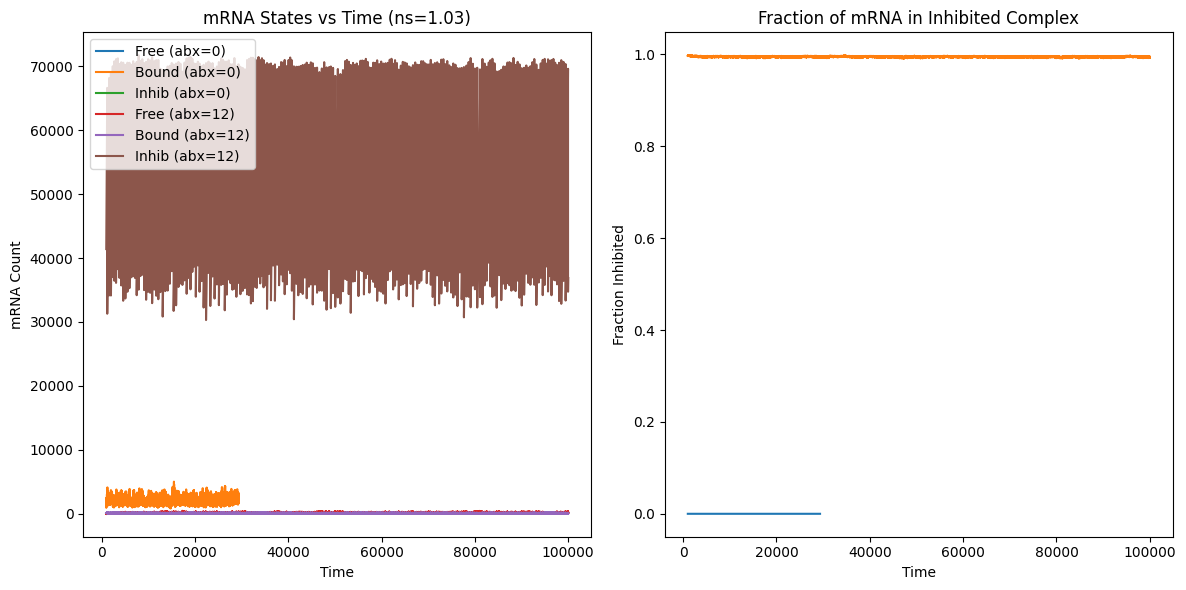

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyarrow as pa
import pyarrow.ipc as ipc

# ------------------------------------------------------------
# PARAMETERS
# ------------------------------------------------------------

NS_CHOICE = 1.03   # change if needed
ABX_COMPARE = [0, 12]
BURN_IN = 1000.0

# ------------------------------------------------------------
# LOAD FUNCTION
# ------------------------------------------------------------

def load_arrow(path):
    with pa.memory_map(path, "r") as src:
        return ipc.open_file(src).read_all().to_pandas()

# ------------------------------------------------------------
# SPLIT mRNA STATES
# ------------------------------------------------------------

def compute_mRNA_states(df):

    free_mRNA = (
        df["mm(t)"] +
        df["mt(t)"] +
        df["mq(t)"] +
        df["mr(t)"]
    ).to_numpy()

    bound_mRNA = (
        df["rmm(t)"] +
        df["rmt(t)"] +
        df["rmq(t)"] +
        df["rmr(t)"]
    ).to_numpy()

    inhibited_mRNA = (
        df["zmm(t)"] +
        df["zmt(t)"] +
        df["zmq(t)"] +
        df["zmr(t)"]
    ).to_numpy()

    return free_mRNA, bound_mRNA, inhibited_mRNA

# ------------------------------------------------------------
# PLOT
# ------------------------------------------------------------

plt.figure(figsize=(12,6))

for abx in ABX_COMPARE:

    path = f"Data/ns{int(NS_CHOICE*100):03d}/abx{abx}.arrow"

    df = load_arrow(path)
    df = df[df["timestamp"] >= BURN_IN]

    t = df["timestamp"].to_numpy()
    free_m, bound_m, inhib_m = compute_mRNA_states(df)

    # Optional: normalize by total to see fractions
    total = free_m + bound_m + inhib_m
    frac_inhib = inhib_m / total

    # Plot absolute values
    plt.subplot(1,2,1)
    plt.plot(t, free_m, label=f"Free (abx={abx})")
    plt.plot(t, bound_m, label=f"Bound (abx={abx})")
    plt.plot(t, inhib_m, label=f"Inhib (abx={abx})")

    # Plot fraction inhibited
    plt.subplot(1,2,2)
    plt.plot(t, frac_inhib, label=f"abx={abx}")

# Formatting
plt.subplot(1,2,1)
plt.xlabel("Time")
plt.ylabel("mRNA Count")
plt.title(f"mRNA States vs Time (ns={NS_CHOICE})")
plt.legend()

plt.subplot(1,2,2)
plt.xlabel("Time")
plt.ylabel("Fraction Inhibited")
plt.title("Fraction of mRNA in Inhibited Complex")

plt.show()

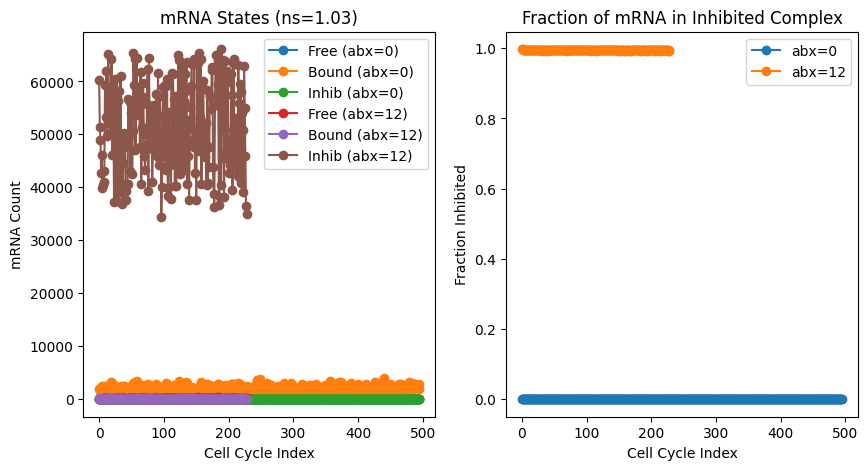

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyarrow as pa
import pyarrow.ipc as ipc

# ------------------------------------------------------------
# PARAMETERS
# ------------------------------------------------------------

NS_CHOICE = 1.03
ABX_COMPARE = [0, 12]
BURN_IN = 1000.0
GUARD_FRAC = 0.1

# ------------------------------------------------------------
# LOAD FUNCTION
# ------------------------------------------------------------

def load_arrow(path):
    with pa.memory_map(path, "r") as src:
        return ipc.open_file(src).read_all().to_pandas()

# ------------------------------------------------------------
# DIVISION DETECTION
# ------------------------------------------------------------

def detect_divisions_from_mass(total_mass):
    dx = np.diff(total_mass)
    slope = np.sign(dx)
    dslope = np.diff(slope)
    return np.where(dslope == -2)[0] + 1

def sample_one_per_cycle(total_mass, guard_frac=0.1, seed=0):
    rng = np.random.default_rng(seed)
    div_idx = detect_divisions_from_mass(total_mass)
    div_idx = np.concatenate(([0], div_idx, [len(total_mass)-1]))

    sample_indices = []

    for i in range(len(div_idx)-1):
        start = div_idx[i]
        end   = div_idx[i+1]
        L = end - start

        if L < 10:
            continue

        g = int(guard_frac * L)
        lo = start + g
        hi = end - g

        if hi > lo:
            sample_indices.append(rng.integers(lo, hi))

    return np.array(sample_indices)

# ------------------------------------------------------------
# COMPUTE TOTAL MASS (needed for division detection)
# ------------------------------------------------------------

NR = 7549.0
NX = 300.0

def compute_total_mass(df):
    r   = df["r(t)"].to_numpy()
    rmm = df["rmm(t)"].to_numpy()
    rmt = df["rmt(t)"].to_numpy()
    rmq = df["rmq(t)"].to_numpy()
    rmr = df["rmr(t)"].to_numpy()
    zmm = df["zmm(t)"].to_numpy()
    zmt = df["zmt(t)"].to_numpy()
    zmq = df["zmq(t)"].to_numpy()
    zmr = df["zmr(t)"].to_numpy()
    q   = df["q(t)"].to_numpy()
    et  = df["et(t)"].to_numpy()
    em  = df["em(t)"].to_numpy()

    ribo_mass = NR * (r + rmm + rmt + rmq + rmr +
                      zmm + zmt + zmq + zmr)
    non_ribo  = NX * (q + et + em)

    return ribo_mass + non_ribo

# ------------------------------------------------------------
# SPLIT mRNA STATES
# ------------------------------------------------------------

def compute_mRNA_states(df):

    free_mRNA = (
        df["mm(t)"] +
        df["mt(t)"] +
        df["mq(t)"] +
        df["mr(t)"]
    ).to_numpy()

    bound_mRNA = (
        df["rmm(t)"] +
        df["rmt(t)"] +
        df["rmq(t)"] +
        df["rmr(t)"]
    ).to_numpy()

    inhibited_mRNA = (
        df["zmm(t)"] +
        df["zmt(t)"] +
        df["zmq(t)"] +
        df["zmr(t)"]
    ).to_numpy()

    return free_mRNA, bound_mRNA, inhibited_mRNA

# ------------------------------------------------------------
# PLOT
# ------------------------------------------------------------

plt.figure(figsize=(10,5))

for abx in ABX_COMPARE:

    path = f"Data/ns{int(NS_CHOICE*100):03d}/abx{abx}.arrow"

    df = load_arrow(path)
    df = df[df["timestamp"] >= BURN_IN]

    total_mass = compute_total_mass(df)
    idx = sample_one_per_cycle(total_mass, guard_frac=GUARD_FRAC)

    free_m, bound_m, inhib_m = compute_mRNA_states(df)

    free_m = free_m[idx]
    bound_m = bound_m[idx]
    inhib_m = inhib_m[idx]

    cycles = np.arange(len(idx))

    plt.subplot(1,2,1)
    plt.plot(cycles, free_m, marker='o', label=f"Free (abx={abx})")
    plt.plot(cycles, bound_m, marker='o', label=f"Bound (abx={abx})")
    plt.plot(cycles, inhib_m, marker='o', label=f"Inhib (abx={abx})")

    total = free_m + bound_m + inhib_m
    frac_inhib = inhib_m / total

    plt.subplot(1,2,2)
    plt.plot(cycles, frac_inhib, marker='o', linestyle='-', label=f"abx={abx}")

# Formatting
plt.subplot(1,2,1)
plt.xlabel("Cell Cycle Index")
plt.ylabel("mRNA Count")
plt.title(f"mRNA States (ns={NS_CHOICE})")
plt.legend()

plt.subplot(1,2,2)
plt.xlabel("Cell Cycle Index")
plt.ylabel("Fraction Inhibited")
plt.title("Fraction of mRNA in Inhibited Complex")
plt.legend()


plt.show()

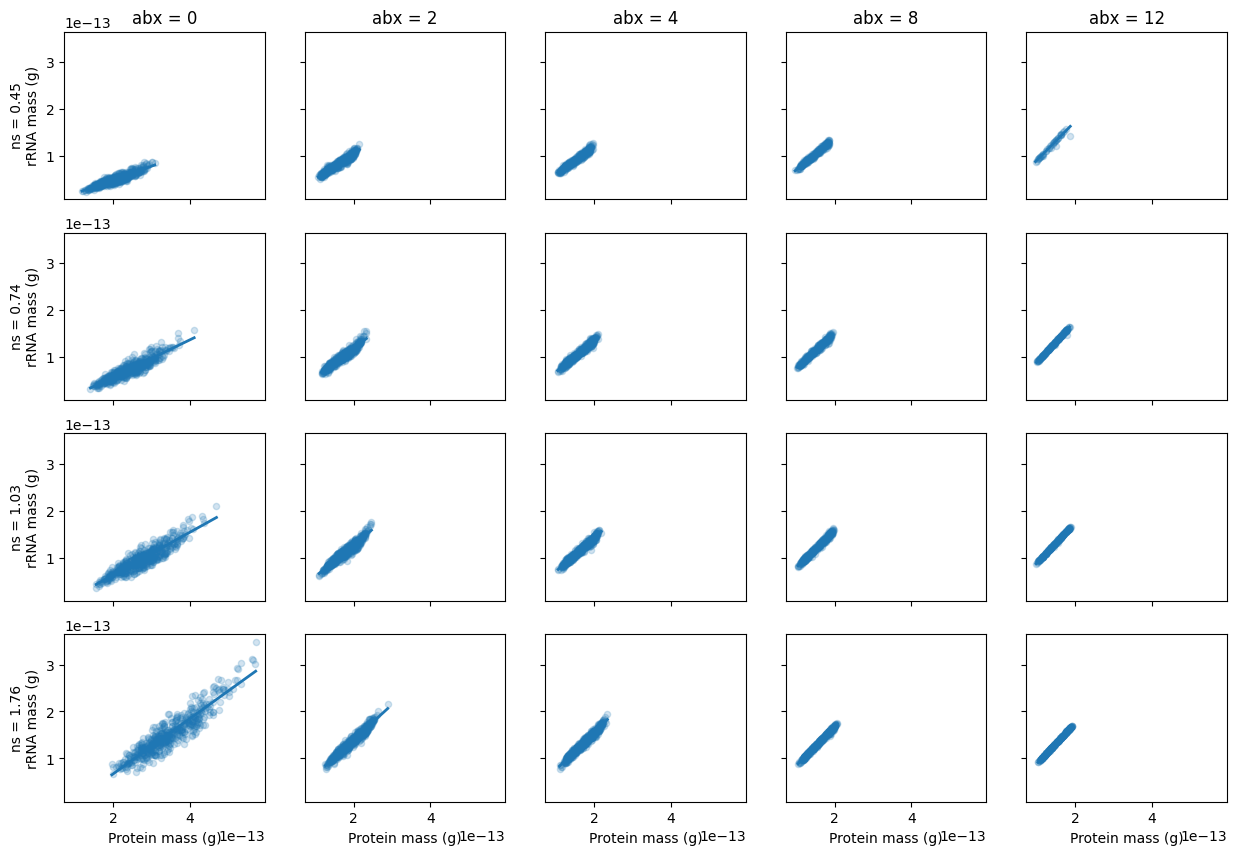

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyarrow as pa
import pyarrow.ipc as ipc

# ============================================================
# PARAMETERS
# ============================================================

NS_VALUES  = [0.45, 0.74, 1.03, 1.76]
ABX_VALUES = [0, 2, 4, 8, 12]

BURN_IN = 1000.0
GUARD_FRAC = 0.1

NR = 7549.0
NX = 300.0
RIBO_RNA_NT = 4565

AVOGADRO = 6.022e23
MW_AA = 110.0
MW_NT = 330.0

# ============================================================
# LOAD
# ============================================================

def load_arrow(path):
    with pa.memory_map(path, "r") as src:
        return ipc.open_file(src).read_all().to_pandas()

# ============================================================
# DIVISION DETECTION
# ============================================================

def detect_divisions_from_mass(total_mass):
    dx = np.diff(total_mass)
    slope = np.sign(dx)
    dslope = np.diff(slope)
    return np.where(dslope == -2)[0] + 1

def sample_one_per_cycle(total_mass, guard_frac=0.1, seed=0):
    rng = np.random.default_rng(seed)
    div_idx = detect_divisions_from_mass(total_mass)
    div_idx = np.concatenate(([0], div_idx, [len(total_mass)-1]))

    sample_indices = []

    for i in range(len(div_idx)-1):
        start = div_idx[i]
        end   = div_idx[i+1]
        L = end - start

        if L < 10:
            continue

        g = int(guard_frac * L)
        lo = start + g
        hi = end - g

        if hi > lo:
            sample_indices.append(rng.integers(lo, hi))

    return np.array(sample_indices)

# ============================================================
# MASS CALCULATIONS
# ============================================================

def compute_total_protein_mass(df):

    r   = df["r(t)"].to_numpy()
    rmm = df["rmm(t)"].to_numpy()
    rmt = df["rmt(t)"].to_numpy()
    rmq = df["rmq(t)"].to_numpy()
    rmr = df["rmr(t)"].to_numpy()
    zmm = df["zmm(t)"].to_numpy()
    zmt = df["zmt(t)"].to_numpy()
    zmq = df["zmq(t)"].to_numpy()
    zmr = df["zmr(t)"].to_numpy()
    q   = df["q(t)"].to_numpy()
    et  = df["et(t)"].to_numpy()
    em  = df["em(t)"].to_numpy()

    ribo_aa = NR * (r + rmm + rmt + rmq + rmr +
                    zmm + zmt + zmq + zmr)
    non_ribo_aa = NX * (q + et + em)

    total_aa = ribo_aa + non_ribo_aa

    return (total_aa / AVOGADRO) * MW_AA

def compute_rRNA_mass(df):

    r_tot = (
        df["r(t)"] + df["rmm(t)"] + df["rmt(t)"] +
        df["rmq(t)"] + df["rmr(t)"] +
        df["zmm(t)"] + df["zmt(t)"] +
        df["zmq(t)"] + df["zmr(t)"]
    ).to_numpy()

    rRNA_nt = r_tot * RIBO_RNA_NT

    return (rRNA_nt / AVOGADRO) * MW_NT

# ============================================================
# PLOT GRID
# ============================================================

fig, axes = plt.subplots(len(NS_VALUES), len(ABX_VALUES),
                         figsize=(15, 10),
                         sharex=True, sharey=True)

for i, ns in enumerate(NS_VALUES):
    for j, abx in enumerate(ABX_VALUES):

        if abx == 0:
            path = f"Data/ns{int(ns*100):03d}.arrow"
        else:
            path = f"Data/ns{int(ns*100):03d}/abx{abx}.arrow"

        df = load_arrow(path)
        df = df[df["timestamp"] >= BURN_IN]

        protein_mass = compute_total_protein_mass(df)
        rRNA_mass = compute_rRNA_mass(df)

        idx = sample_one_per_cycle(protein_mass, guard_frac=GUARD_FRAC)

        protein_mass = protein_mass[idx]
        rRNA_mass = rRNA_mass[idx]

        ax = axes[i, j]

        ax.scatter(protein_mass, rRNA_mass,
                   s=20, alpha=0.2)

        if len(protein_mass) > 2:
            coef = np.polyfit(protein_mass, rRNA_mass, 1)
            x_grid = np.linspace(protein_mass.min(),
                                 protein_mass.max(), 100)
            y_pred = np.polyval(coef, x_grid)
            ax.plot(x_grid, y_pred, linewidth=2)

        if i == 0:
            ax.set_title(f"abx = {abx}")

        if j == 0:
            ax.set_ylabel(f"ns = {ns}\nrRNA mass (g)")

        if i == len(NS_VALUES)-1:
            ax.set_xlabel("Protein mass (g)")

        ax.grid(False)


plt.show()

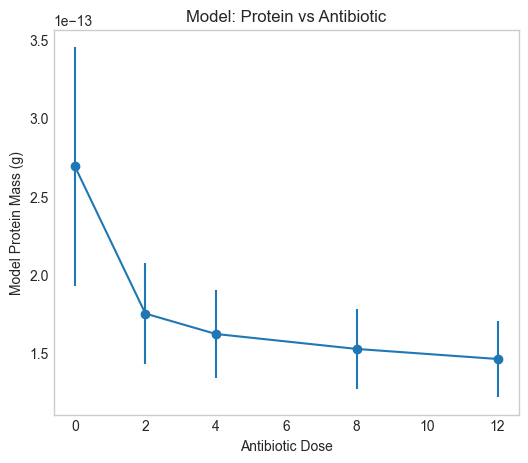

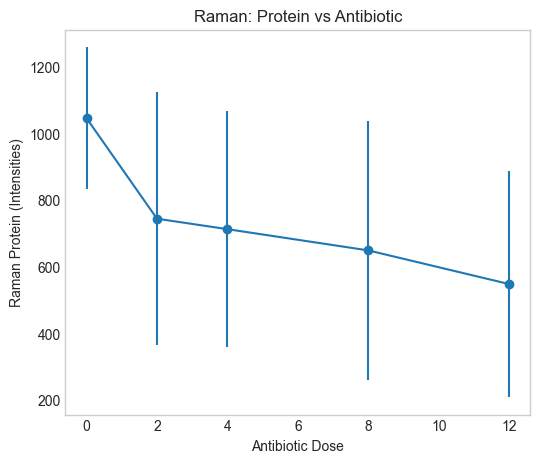

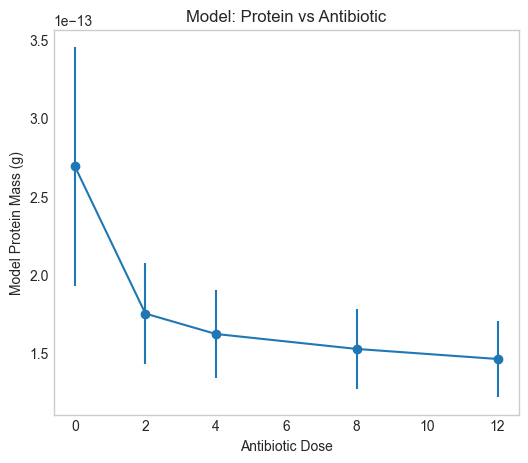

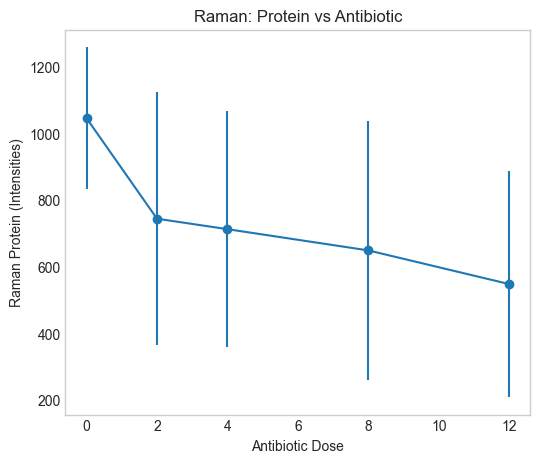

In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyarrow as pa
import pyarrow.ipc as ipc

# ============================================================
# PARAMETERS
# ============================================================

NS_VALUES  = [0.45, 0.74, 1.03, 1.76]
ABX_VALUES = [0, 2, 4, 8, 12]

BURN_IN = 1000.0
GUARD_FRAC = 0.1

NR = 7549.0
NX = 300.0

AVOGADRO = 6.022e23
MW_AA = 110.0

# ============================================================
# LOAD
# ============================================================

def load_arrow(path):
    with pa.memory_map(path, "r") as src:
        return ipc.open_file(src).read_all().to_pandas()

# ============================================================
# DIVISION DETECTION
# ============================================================

def detect_divisions_from_mass(total_mass):
    dx = np.diff(total_mass)
    slope = np.sign(dx)
    dslope = np.diff(slope)
    return np.where(dslope == -2)[0] + 1

def sample_one_per_cycle(total_mass, guard_frac=0.1, seed=0):
    rng = np.random.default_rng(seed)
    div_idx = detect_divisions_from_mass(total_mass)
    div_idx = np.concatenate(([0], div_idx, [len(total_mass)-1]))

    sample_indices = []

    for i in range(len(div_idx)-1):
        start = div_idx[i]
        end   = div_idx[i+1]
        L = end - start

        if L < 10:
            continue

        g = int(guard_frac * L)
        lo = start + g
        hi = end - g

        if hi > lo:
            sample_indices.append(rng.integers(lo, hi))

    return np.array(sample_indices)

# ============================================================
# MODEL PROTEIN MASS
# ============================================================

def compute_protein_mass(df):

    r   = df["r(t)"].to_numpy()
    rmm = df["rmm(t)"].to_numpy()
    rmt = df["rmt(t)"].to_numpy()
    rmq = df["rmq(t)"].to_numpy()
    rmr = df["rmr(t)"].to_numpy()
    zmm = df["zmm(t)"].to_numpy()
    zmt = df["zmt(t)"].to_numpy()
    zmq = df["zmq(t)"].to_numpy()
    zmr = df["zmr(t)"].to_numpy()
    q   = df["q(t)"].to_numpy()
    et  = df["et(t)"].to_numpy()
    em  = df["em(t)"].to_numpy()

    ribo_aa = NR * (r + rmm + rmt + rmq + rmr +
                    zmm + zmt + zmq + zmr)
    non_ribo_aa = NX * (q + et + em)

    total_aa = ribo_aa + non_ribo_aa

    return (total_aa / AVOGADRO) * MW_AA

# ============================================================
# MODEL SUMMARY
# ============================================================

model_means = []
model_stds  = []

for abx in ABX_VALUES:

    protein_all = []

    for ns in NS_VALUES:

        path = f"Data/ns{int(ns*100):03d}/abx{abx}.arrow"

        df = load_arrow(path)
        df = df[df["timestamp"] >= BURN_IN]

        protein_mass = compute_protein_mass(df)

        idx = sample_one_per_cycle(protein_mass, guard_frac=GUARD_FRAC)

        protein_all.append(protein_mass[idx])

    protein_all = np.concatenate(protein_all)

    model_means.append(np.mean(protein_all))
    model_stds.append(np.std(protein_all))

# ============================================================
# RAMAN PROTEIN
# ============================================================

protein_df = pd.read_csv("Data/RamanData/protein.csv")
growth_df  = pd.read_csv("Data/RamanData/Raman_growth.csv")

nutrients = growth_df["Condition"].unique()

raman_means = []
raman_stds  = []

for cm in ABX_VALUES:

    protein_all = []

    for nutrient in nutrients:

        col = f"Cm{cm}_{nutrient}"
        if col not in protein_df.columns:
            continue

        PROT = protein_df[col].dropna().values
        protein_all.append(PROT)

    protein_all = np.concatenate(protein_all)

    raman_means.append(np.mean(protein_all))
    raman_stds.append(np.std(protein_all))

# ============================================================
# PLOT 1 — MODEL
# ============================================================

plt.figure(figsize=(6,5))

plt.errorbar(ABX_VALUES, model_means, yerr=model_stds,
             marker='o')

plt.xlabel("Antibiotic Dose")
plt.ylabel("Model Protein Mass (g)")
plt.title("Model: Protein vs Antibiotic")
plt.grid(False)
plt.show()

# ============================================================
# PLOT 2 — RAMAN
# ============================================================

plt.figure(figsize=(6,5))

plt.errorbar(ABX_VALUES, raman_means, yerr=raman_stds,
             marker='o')

plt.xlabel("Antibiotic Dose")
plt.ylabel("Raman Protein (Intensities)")
plt.title("Raman: Protein vs Antibiotic")
plt.grid(False)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyarrow as pa
import pyarrow.ipc as ipc

# ============================================================
# PARAMETERS
# ============================================================

NS_VALUES  = [0.45, 0.74, 1.03, 1.76]
ABX_VALUES = [0, 2, 4, 8, 12]

BURN_IN = 1000.0
GUARD_FRAC = 0.1

NR = 7549.0
NX = 300.0

AVOGADRO = 6.022e23
MW_AA = 110.0

# ============================================================
# LOAD
# ============================================================

def load_arrow(path):
    with pa.memory_map(path, "r") as src:
        return ipc.open_file(src).read_all().to_pandas()

# ============================================================
# DIVISION DETECTION
# ============================================================

def detect_divisions_from_mass(total_mass):
    dx = np.diff(total_mass)
    slope = np.sign(dx)
    dslope = np.diff(slope)
    return np.where(dslope == -2)[0] + 1

def sample_one_per_cycle(total_mass, guard_frac=0.1, seed=0):
    rng = np.random.default_rng(seed)
    div_idx = detect_divisions_from_mass(total_mass)
    div_idx = np.concatenate(([0], div_idx, [len(total_mass)-1]))

    sample_indices = []

    for i in range(len(div_idx)-1):
        start = div_idx[i]
        end   = div_idx[i+1]
        L = end - start

        if L < 10:
            continue

        g = int(guard_frac * L)
        lo = start + g
        hi = end - g

        if hi > lo:
            sample_indices.append(rng.integers(lo, hi))

    return np.array(sample_indices)

# ============================================================
# MODEL PROTEIN MASS
# ============================================================

def compute_protein_mass(df):

    r   = df["r(t)"].to_numpy()
    rmm = df["rmm(t)"].to_numpy()
    rmt = df["rmt(t)"].to_numpy()
    rmq = df["rmq(t)"].to_numpy()
    rmr = df["rmr(t)"].to_numpy()
    zmm = df["zmm(t)"].to_numpy()
    zmt = df["zmt(t)"].to_numpy()
    zmq = df["zmq(t)"].to_numpy()
    zmr = df["zmr(t)"].to_numpy()
    q   = df["q(t)"].to_numpy()
    et  = df["et(t)"].to_numpy()
    em  = df["em(t)"].to_numpy()

    ribo_aa = NR * (r + rmm + rmt + rmq + rmr +
                    zmm + zmt + zmq + zmr)
    non_ribo_aa = NX * (q + et + em)

    total_aa = ribo_aa + non_ribo_aa

    return (total_aa / AVOGADRO) * MW_AA

# ============================================================
# MODEL SUMMARY
# ============================================================

model_means = []
model_stds  = []

for abx in ABX_VALUES:

    protein_all = []

    for ns in NS_VALUES:

        path = f"Data/ns{int(ns*100):03d}/abx{abx}.arrow"

        df = load_arrow(path)
        df = df[df["timestamp"] >= BURN_IN]

        protein_mass = compute_protein_mass(df)

        idx = sample_one_per_cycle(protein_mass, guard_frac=GUARD_FRAC)

        protein_all.append(protein_mass[idx])

    protein_all = np.concatenate(protein_all)

    model_means.append(np.mean(protein_all))
    model_stds.append(np.std(protein_all))

# ============================================================
# RAMAN PROTEIN
# ============================================================

protein_df = pd.read_csv("Data/RamanData/protein.csv")
growth_df  = pd.read_csv("Data/RamanData/Raman_growth.csv")

nutrients = growth_df["Condition"].unique()

raman_means = []
raman_stds  = []

for cm in ABX_VALUES:

    protein_all = []

    for nutrient in nutrients:

        col = f"Cm{cm}_{nutrient}"
        if col not in protein_df.columns:
            continue

        PROT = protein_df[col].dropna().values
        protein_all.append(PROT)

    protein_all = np.concatenate(protein_all)

    raman_means.append(np.mean(protein_all))
    raman_stds.append(np.std(protein_all))

# ============================================================
# PLOT 1 — MODEL
# ============================================================

plt.figure(figsize=(6,5))

plt.errorbar(ABX_VALUES, model_means, yerr=model_stds,
             marker='o')

plt.xlabel("Antibiotic Dose")
plt.ylabel("Model Protein Mass (g)")
plt.title("Model: Protein vs Antibiotic")
plt.grid(False)
plt.show()

# ============================================================
# PLOT 2 — RAMAN
# ============================================================

plt.figure(figsize=(6,5))

plt.errorbar(ABX_VALUES, raman_means, yerr=raman_stds,
             marker='o')

plt.xlabel("Antibiotic Dose")
plt.ylabel("Raman Protein (Intensities)")
plt.title("Raman: Protein vs Antibiotic")
plt.grid(False)
plt.show()

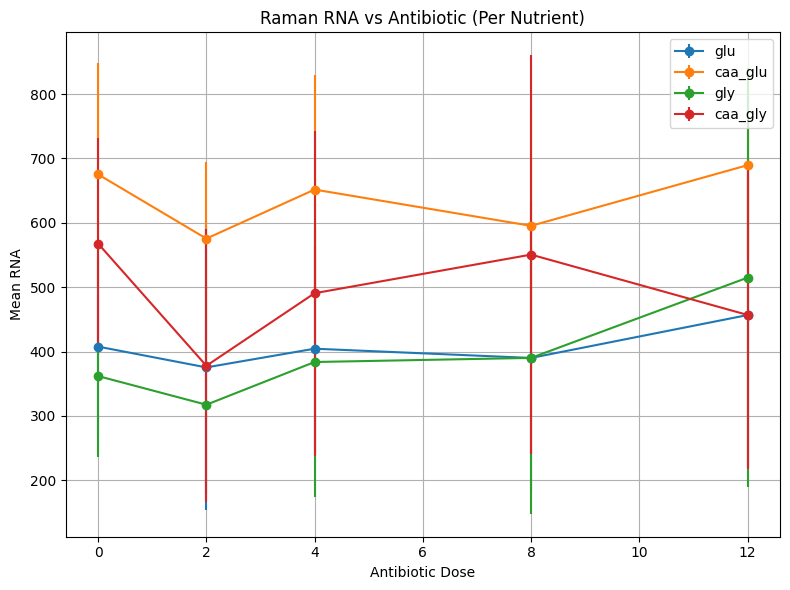

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# LOAD DATA
# ============================================================

rna_df = pd.read_csv("Data/RamanData/rna.csv")
growth_df = pd.read_csv("Data/RamanData/Raman_growth.csv")

nutrients = growth_df["Condition"].unique()
ABX_VALUES = sorted(growth_df["Dose"].unique())

# ============================================================
# PLOT
# ============================================================

plt.figure(figsize=(8,6))

for nutrient in nutrients:

    means = []
    stds  = []

    for cm in ABX_VALUES:

        col = f"Cm{cm}_{nutrient}"

        if col not in rna_df.columns:
            means.append(np.nan)
            stds.append(np.nan)
            continue

        RNA = rna_df[col].dropna().values

        # Remove negative values if needed
        RNA = RNA[RNA > 0]

        means.append(np.mean(RNA))
        stds.append(np.std(RNA))

    plt.errorbar(ABX_VALUES, means, yerr=stds,
                 marker='o', label=nutrient)

plt.xlabel("Antibiotic Dose")
plt.ylabel("Mean RNA")
plt.title("Raman RNA vs Antibiotic (Per Nutrient)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

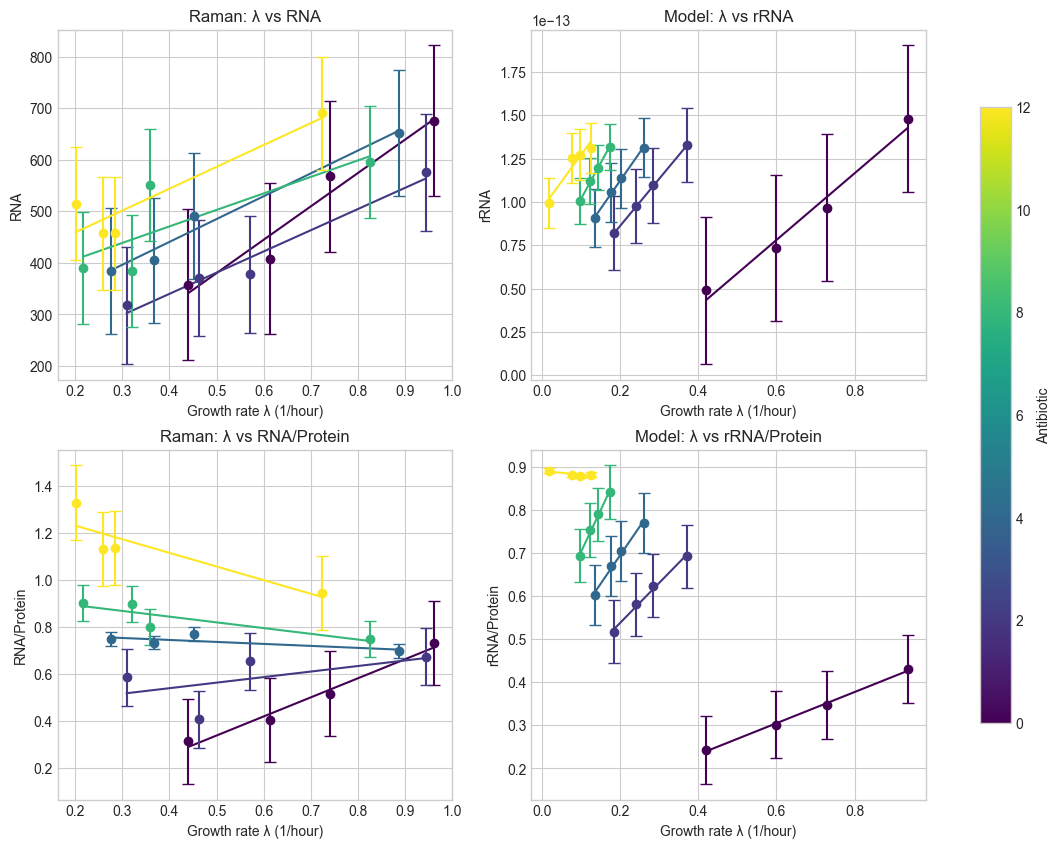

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import pyarrow as pa
import pyarrow.ipc as ipc

plt.style.use("seaborn-v0_8-whitegrid")

# ============================================================
# PARAMETERS
# ============================================================

NS_VALUES  = [0.45, 0.74, 1.03, 1.76]
ABX_VALUES = [0, 2, 4, 8, 12]
BURN_IN = 1000.0

NR = 7549.0
NX = 300.0
RIBO_RNA_NT = 4565
AVOGADRO = 6.022e23
MW_AA = 110.0
MW_NT = 330.0

# ============================================================
# LOADERS
# ============================================================

def load_arrow(path):
    with pa.memory_map(path, "r") as src:
        return ipc.open_file(src).read_all().to_pandas()

# ============================================================
# MODEL HELPERS
# ============================================================

def compute_rRNA_mass(df):
    r_tot = (
        df["r(t)"] + df["rmm(t)"] + df["rmt(t)"] +
        df["rmq(t)"] + df["rmr(t)"] +
        df["zmm(t)"] + df["zmt(t)"] +
        df["zmq(t)"] + df["zmr(t)"]
    ).to_numpy()

    rRNA_nt = r_tot * RIBO_RNA_NT
    return (rRNA_nt / AVOGADRO) * MW_NT

def compute_protein_mass(df):
    r   = df["r(t)"]
    rmm = df["rmm(t)"]
    rmt = df["rmt(t)"]
    rmq = df["rmq(t)"]
    rmr = df["rmr(t)"]
    zmm = df["zmm(t)"]
    zmt = df["zmt(t)"]
    zmq = df["zmq(t)"]
    zmr = df["zmr(t)"]
    q   = df["q(t)"]
    et  = df["et(t)"]
    em  = df["em(t)"]

    ribo_mass = NR * (r + rmm + rmt + rmq + rmr +
                      zmm + zmt + zmq + zmr)

    non_ribo  = NX * (q + et + em)
    total_aa  = (ribo_mass + non_ribo).to_numpy()

    return (total_aa / AVOGADRO) * MW_AA

def compute_mass_components(df):
    r   = df["r(t)"].to_numpy()
    rmm = df["rmm(t)"].to_numpy()
    rmt = df["rmt(t)"].to_numpy()
    rmq = df["rmq(t)"].to_numpy()
    rmr = df["rmr(t)"].to_numpy()
    zmm = df["zmm(t)"].to_numpy()
    zmt = df["zmt(t)"].to_numpy()
    zmq = df["zmq(t)"].to_numpy()
    zmr = df["zmr(t)"].to_numpy()
    q   = df["q(t)"].to_numpy()
    et  = df["et(t)"].to_numpy()
    em  = df["em(t)"].to_numpy()

    ribo_total = (r + rmm + rmt + rmq + rmr +
                  zmm + zmt + zmq + zmr)

    ribo_mass = NR * ribo_total
    non_ribo  = NX * (q + et + em)
    total_mass = ribo_mass + non_ribo

    return total_mass

def compute_growth(df, total_mass):
    a = df["a(t)"].to_numpy()
    gamma = GMAX * a / ((KGAMMA * total_mass / 1e8) + a)

    active = (
        df["rmr(t)"].to_numpy() +
        df["rmt(t)"].to_numpy() +
        df["rmm(t)"].to_numpy() +
        df["rmq(t)"].to_numpy()
    )

    lam = (active * gamma / total_mass) * 60.0
    return lam

# ============================================================
# BUILD MODEL SUMMARY
# ============================================================

model_records = []

for ns in NS_VALUES:
    for abx in ABX_VALUES:

        path = f"Data/ns{int(ns*100):03d}/abx{abx}.arrow"
        df = load_arrow(path)
        df = df[df["timestamp"] >= BURN_IN]

        rRNA = compute_rRNA_mass(df)
        protein = compute_protein_mass(df)
        total_mass = compute_mass_components(df)

        lam = compute_growth(df, total_mass) # adjust if different

        model_records.append({
            "ns": ns,
            "abx": abx,
            "lambda": np.mean(lam),
            "rRNA_mean": np.mean(rRNA),
            "ratio_mean": np.mean(rRNA / protein)
        })

df_model = pd.DataFrame(model_records)

# ============================================================
# BUILD RAMAN SUMMARY
# ============================================================

rna_df = pd.read_csv("Data/RamanData/rna.csv")
protein_df = pd.read_csv("Data/RamanData/protein.csv")
growth_df = pd.read_csv("Data/RamanData/Raman_growth.csv")

raman_records = []

for nutrient in growth_df["Condition"].unique():
    for abx in ABX_VALUES:

        col = f"Cm{abx}_{nutrient}"
        if col not in rna_df.columns:
            continue

        RNA  = rna_df[col].dropna().values
        PROT = protein_df[col].dropna().values

        N = min(len(RNA), len(PROT))
        RNA = RNA[:N]
        PROT = PROT[:N]

        mu = growth_df[
            (growth_df["Condition"] == nutrient) &
            (growth_df["Dose"] == abx)
        ]["Value"].values[0]

        raman_records.append({
            "nutrient": nutrient,
            "abx": abx,
            "lambda": mu,
            "RNA_mean": np.mean(RNA),
            "ratio_mean": np.mean(RNA / PROT)
        })

df_raman = pd.DataFrame(raman_records)

# ============================================================
# PLOTTING WITH ERROR BARS (Across Nutrients)
# ============================================================

fig, axes = plt.subplots(2,2, figsize=(14,10))

norm = mcolors.Normalize(vmin=min(ABX_VALUES), vmax=max(ABX_VALUES))
cmap = cm.viridis

# Helper: compute mean + SD across nutrients
def mean_sd(subset, x_col, y_col):
    return (
        subset[x_col].mean(),
        subset[y_col].mean(),
        subset[y_col].std()
    )

# =========================
# Raman λ vs RNA
# =========================
for abx in ABX_VALUES:
    subset = df_raman[df_raman["abx"] == abx]

    x = subset["lambda"].values
    y = subset["RNA_mean"].values

    axes[0,0].errorbar(
        x, y,
        yerr=subset["RNA_mean"].std(),
        fmt='o',
        color=cmap(norm(abx)),
        capsize=4
    )

    if len(x) > 1:
        slope, intercept = np.polyfit(x, y, 1)
        x_line = np.linspace(min(x), max(x), 100)
        axes[0,0].plot(x_line, slope*x_line + intercept,
                       color=cmap(norm(abx)))

axes[0,0].set_title("Raman: λ vs RNA")
axes[0,0].set_ylabel("RNA (intensities)")

# =========================
# Model λ vs rRNA
# =========================
for abx in ABX_VALUES:
    subset = df_model[df_model["abx"] == abx]

    x = subset["lambda"].values
    y = subset["rRNA_mean"].values

    axes[0,1].errorbar(
        x, y,
        yerr=subset["rRNA_mean"].std(),
        fmt='o',
        color=cmap(norm(abx)),
        capsize=4
    )

    if len(x) > 1:
        slope, intercept = np.polyfit(x, y, 1)
        x_line = np.linspace(min(x), max(x), 100)
        axes[0,1].plot(x_line, slope*x_line + intercept,
                       color=cmap(norm(abx)))

axes[0,1].set_title("Model: λ vs rRNA")
axes[0,1].set_ylabel("rRNA (grams)")

# =========================
# Raman λ vs RNA/Protein
# =========================
for abx in ABX_VALUES:
    subset = df_raman[df_raman["abx"] == abx]

    x = subset["lambda"].values
    y = subset["ratio_mean"].values

    axes[1,0].errorbar(
        x, y,
        yerr=subset["ratio_mean"].std(),
        fmt='o',
        color=cmap(norm(abx)),
        capsize=4
    )

    if len(x) > 1:
        slope, intercept = np.polyfit(x, y, 1)
        x_line = np.linspace(min(x), max(x), 100)
        axes[1,0].plot(x_line, slope*x_line + intercept,
                       color=cmap(norm(abx)))

axes[1,0].set_title("Raman: λ vs RNA/Protein")
axes[1,0].set_ylabel("RNA/Protein")

# =========================
# Model λ vs rRNA/Protein
# =========================
for abx in ABX_VALUES:
    subset = df_model[df_model["abx"] == abx]

    x = subset["lambda"].values
    y = subset["ratio_mean"].values

    axes[1,1].errorbar(
        x, y,
        yerr=subset["ratio_mean"].std(),
        fmt='o',
        color=cmap(norm(abx)),
        capsize=4
    )

    if len(x) > 1:
        slope, intercept = np.polyfit(x, y, 1)
        x_line = np.linspace(min(x), max(x), 100)
        axes[1,1].plot(x_line, slope*x_line + intercept,
                       color=cmap(norm(abx)))

axes[1,1].set_title("Model: λ vs rRNA/Protein")
axes[1,1].set_ylabel("rRNA/Protein")

# Formatting
for ax in axes.flat:
    ax.set_xlabel("Growth rate λ (1/hour)")

cbar = fig.colorbar(
    cm.ScalarMappable(norm=norm, cmap=cmap),
    ax=axes,
    shrink=0.8
)
cbar.set_label("Antibiotic")

plt.show()